In [1]:
import os
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, 
    Activation, 
    BatchNormalization, 
    MaxPooling2D, 
    Dropout, 
    Flatten, 
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
# Loading training, testing, and validation directories
train_dir = '../../data/plant-disease/Train/Train'
test_dir = '../../data/plant-disease/Test/Test'
val_dir = '../../data/plant-disease/Validation/Validation'

In [3]:
# Put them in a dictionary to loop through easily
directories = {
    "Train": train_dir,
    "Test": test_dir,
    "Validation": val_dir
}

print("***** Number of files in each folder *****\n")

for name, path in directories.items():
    total_files = 0
    
    # os.walk loops through the subfolders (Healthy, Powdery, Rust)
    for dirpath, _, filenames in os.walk(path):
        # Filter out any hidden system files if they exist
        visible_files = [f for f in filenames if not f.startswith('.')]
        
        if visible_files:
            file_count = len(visible_files)
            # This extracts just the category name (e.g., 'Healthy') from the full path
            category = os.path.basename(dirpath) 
            
            print(f"{name}/{category}: {file_count}")
            total_files += file_count
            
    print(f"Total: {total_files}")
    print("-" * 80)

***** Number of files in each folder *****

Train/Powdery: 430
Train/Healthy: 458
Train/Rust: 434
Total: 1322
--------------------------------------------------------------------------------
Test/Powdery: 50
Test/Healthy: 50
Test/Rust: 50
Total: 150
--------------------------------------------------------------------------------
Validation/Powdery: 20
Validation/Healthy: 20
Validation/Rust: 20
Total: 60
--------------------------------------------------------------------------------


In [4]:
# Valid image extensions to check
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')

# Combine paths to scan all image files across the entire dataset
all_dirs = [train_dir, test_dir, val_dir]
all_dimensions = []

for base_path in all_dirs:
    for dirpath, _, filenames in os.walk(base_path):
        for filename in filenames:
            if filename.lower().endswith(valid_extensions):
                file_path = os.path.join(dirpath, filename)
                try:
                    # Open the image to read dimensions without loading pixel data into memory
                    with Image.open(file_path) as img:
                        # img.size returns (width, height)
                        all_dimensions.append(img.size)
                except Exception as e:
                    # Skips corrupted files if any
                    continue


In [5]:
# 1. Find unique image dimensions
unique_dimensions = set(all_dimensions)
print(f"Found {len(unique_dimensions)} unique image dimensions: {unique_dimensions}\n")

Found 8 unique image dimensions: {(4032, 3024), (4000, 2672), (4000, 3000), (5184, 3456), (2592, 1728), (3901, 2607), (4608, 3456), (2421, 2279)}



In [6]:
# 2. Compute the distribution of these dimensions
dimension_counts = Counter(all_dimensions)

print("***** Dimension Distribution *****")
for dimension, count in dimension_counts.items():
    print(f"Dimension {dimension}: {count} images")

***** Dimension Distribution *****
Dimension (4000, 2672): 1130 images
Dimension (4000, 3000): 88 images
Dimension (2421, 2279): 1 images
Dimension (4608, 3456): 72 images
Dimension (2592, 1728): 127 images
Dimension (5184, 3456): 97 images
Dimension (4032, 3024): 16 images
Dimension (3901, 2607): 1 images


In [7]:
# Tracking sets for data types and global min/max pixel values
unique_dtypes = set()
global_min = 255
global_max = 0
not_uint8_count = 0
total_images = 0

print("Scanning images for data types and pixel ranges...\n")

for base_path in all_dirs:
    for dirpath, _, filenames in os.walk(base_path):
        for filename in filenames:
            if filename.lower().endswith(valid_extensions):
                file_path = os.path.join(dirpath, filename)
                try:
                    with Image.open(file_path) as img:
                        # Convert image to a numpy array to inspect raw pixels and dtypes
                        img_array = np.array(img)
                        
                        total_images += 1
                        dtype_str = str(img_array.dtype)
                        unique_dtypes.add(dtype_str)
                        
                        if dtype_str != 'uint8':
                            not_uint8_count += 1
                        
                        # Find the minimum and maximum pixel values in this image
                        img_min = img_array.min()
                        img_max = img_array.max()
                        
                        # Update global metrics
                        if img_min < global_min: global_min = img_min
                        if img_max > global_max: global_max = img_max
                        
                except Exception as e:
                    # Skip any unreadable or corrupted files
                    continue

Scanning images for data types and pixel ranges...



In [8]:
print("-" * 50)

--------------------------------------------------


In [9]:
# 1. Output for Data Type check
print(f"Unique data types found: {list(unique_dtypes)}")
if not_uint8_count > 0:
    print(f"- Not all images are of data type uint8 ({not_uint8_count}/{total_images} images are different)")
else:
    print("- All images are of data type uint8")

print()

Unique data types found: []
- All images are of data type uint8



In [10]:
# 2. Output for Pixel Range check
print(f"Global pixel value range: Min = {global_min}, Max = {global_max}")
if global_min >= 0 and global_max <= 255:
    print("- All images have pixel values ranging from 0 to 255")
else:
    print(f"- Warning: Found pixel values outside the 0-255 range!")
print("-" * 50)

Global pixel value range: Min = 255, Max = 0
- All images have pixel values ranging from 0 to 255
--------------------------------------------------


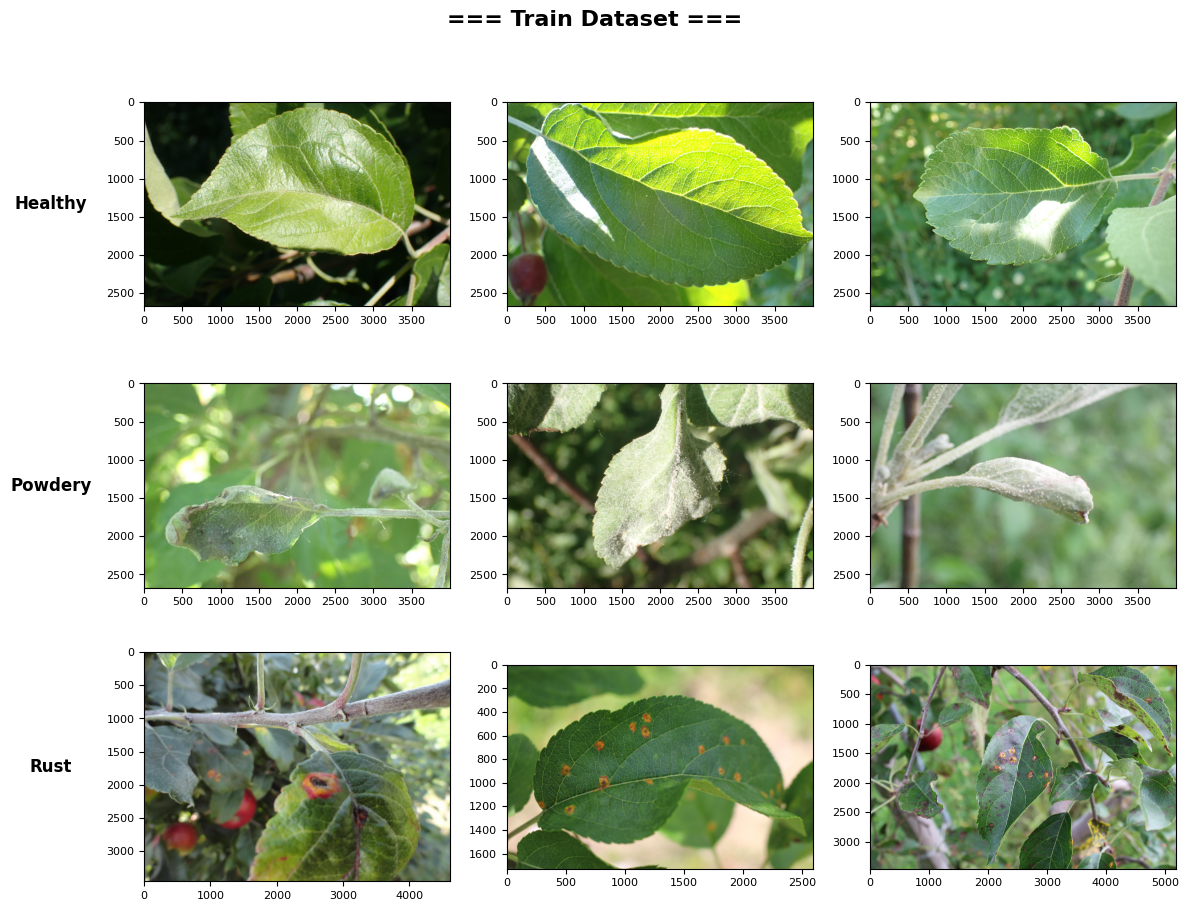

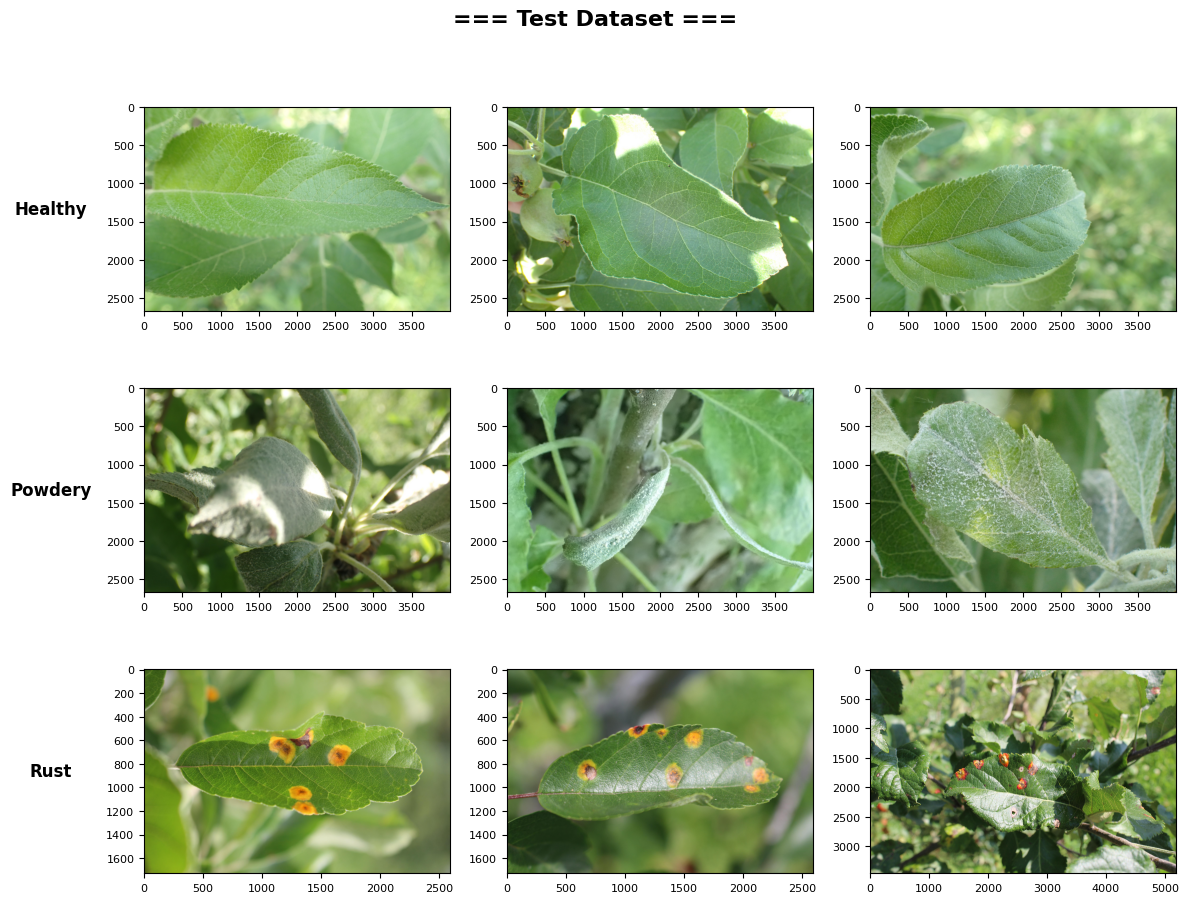

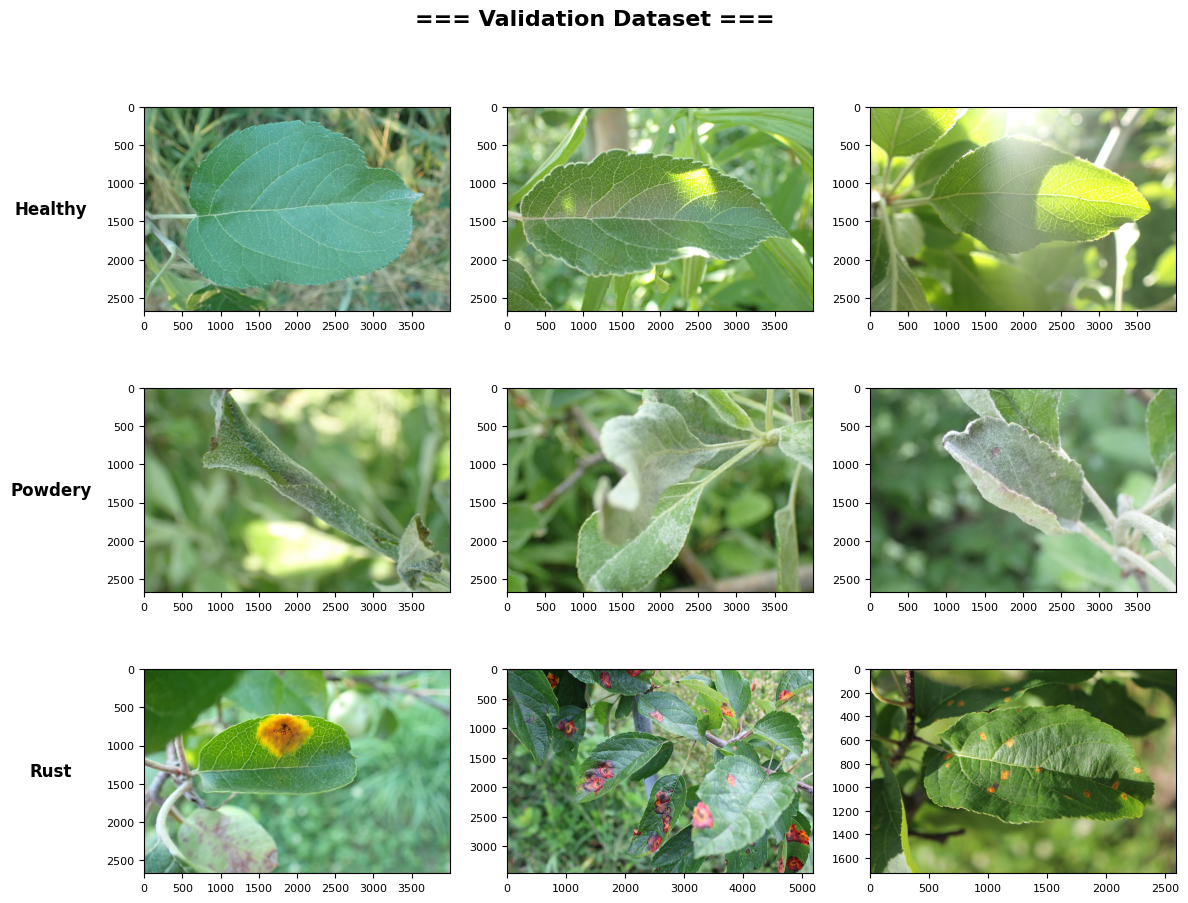

In [11]:
datasets = {
    "Train Dataset": train_dir,
    "Test Dataset": test_dir,
    "Validation Dataset": val_dir
}
# Loop through each dataset split to create a separate figure
for dataset_name, dataset_path in datasets.items():
    # Find all subfolders (classes) inside this directory
    categories = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    
    # Setup a grid layout: Rows = Number of classes, Columns = 3 images per class
    fig, axes = plt.subplots(len(categories), 3, figsize=(12, 3 * len(categories)))
    fig.suptitle(f"=== {dataset_name} ===", fontsize=16, fontweight='bold', y=1.02)
    
    for row_idx, category in enumerate(categories):
        category_path = os.path.join(dataset_path, category)
        
        # Gather all valid image filenames in the subfolder
        images = [f for f in os.listdir(category_path) if f.lower().endswith(valid_extensions)]
        # Pick up to the first 3 images
        sample_images = images[:3]
        
        for col_idx in range(3):
            ax = axes[row_idx, col_idx] if len(categories) > 1 else axes[col_idx]
            
            if col_idx < len(sample_images):
                img_path = os.path.join(category_path, sample_images[col_idx])
                img = Image.open(img_path)
                
                ax.imshow(img)
                # Show the category name on the leftmost column image
                if col_idx == 0:
                    ax.set_ylabel(category, fontsize=12, fontweight='bold', rotation=0, labelpad=40, va='center')
            else:
                # If a folder has fewer than 3 images, leave the subplot blank
                ax.text(0.5, 0.5, 'No Image', ha='center', va='center')
            
            # Keep the axis ticks visible as per standard image dimension checks
            ax.tick_params(axis='both', which='major', labelsize=8)
            
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

<h4>For those familiar with tabular data, preprocessing is probably one of the most daunting steps of dealing with neural networks and unstructured data.

This task can be fairly easy by using TensorFlow’s image_dataset_from_directory, which loads images from the directories as a TensorFlow Dataset. This resulting dataset can be manipulated for batching, shuffling, augmentating, and several other preprocessing steps.</h4>

In [12]:
# Set a constant integer as your random seed
seed = 42
# Creating a Dataset for the Training data
train = tf.keras.utils.image_dataset_from_directory(
    train_dir,  # Directory where the Training images are located
    labels = 'inferred', # Classes will be inferred according to the structure of the directory
    label_mode = 'categorical',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    # Number of processed samples before updating the model's weights
    image_size = (256, 256), # Defining a fixed dimension for all images
    shuffle = True,  # Shuffling data
    seed = seed,  # Random seed for shuffling and transformations
    validation_split = 0, # We don't need to create a validation set from the training set
    crop_to_aspect_ratio = True # Resize images without aspect ratio distortion
)

Found 1322 files belonging to 3 classes.


2026-07-17 21:30:01.225515: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-07-17 21:30:01.225655: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-17 21:30:01.225659: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1784304001.226090 2874473 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1784304001.226548 2874473 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [13]:
# Creating a dataset for the Test data
test = tf.keras.utils.image_dataset_from_directory(
    test_dir,  
    labels = 'inferred', 
    label_mode = 'categorical',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    
    image_size = (256, 256), 
    shuffle = True,  
    seed = seed,  
    validation_split = 0, 
    crop_to_aspect_ratio = True 
)

Found 150 files belonging to 3 classes.


In [14]:
# Creating a dataset for the Validation data
validation = tf.keras.utils.image_dataset_from_directory(
    val_dir,  
    labels = 'inferred', 
    label_mode = 'categorical',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    
    image_size = (256, 256),
    shuffle = True,  
    seed = seed,  
    validation_split = 0, 
    crop_to_aspect_ratio = True 
)

Found 60 files belonging to 3 classes.


In [23]:
print('\nTraining Dataset:', train)
print('\nTesting Dataset:', test)
print('\nValidation Dataset:', validation)


Training Dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>

Testing Dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>

Validation Dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>


In [15]:
# Initialize min and max trackers
min_val = float('inf')
max_val = float('-inf')

# Iterate through the validation dataset batches
for images, labels in validation:
    # Convert the tensor batch to a numpy array
    images_numpy = images.numpy()
    
    # Find the min and max of the current batch
    batch_min = images_numpy.min()
    batch_max = images_numpy.max()
    
    # Update the global min and max
    if batch_min < min_val:
        min_val = batch_min
    if batch_max > max_val:
        max_val = batch_max

# Print the final formatted output
print(f"Minimum pixel value in the Validation dataset {min_val:.1f}")
print(f"Maximum pixel value in the Validation dataset {max_val:.1f}")

Minimum pixel value in the Validation dataset 0.0
Maximum pixel value in the Validation dataset 255.0


2026-07-17 21:30:12.212896: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
scaler = tf.keras.layers.Rescaling(1./255) # Defining scaler values between 0 to 1
# Rescaling datasets
train = train.map(lambda x, y: (scaler(x), y)) 
test = test.map(lambda x, y: (scaler(x), y))
validation = validation.map(lambda x, y: (scaler(x), y))

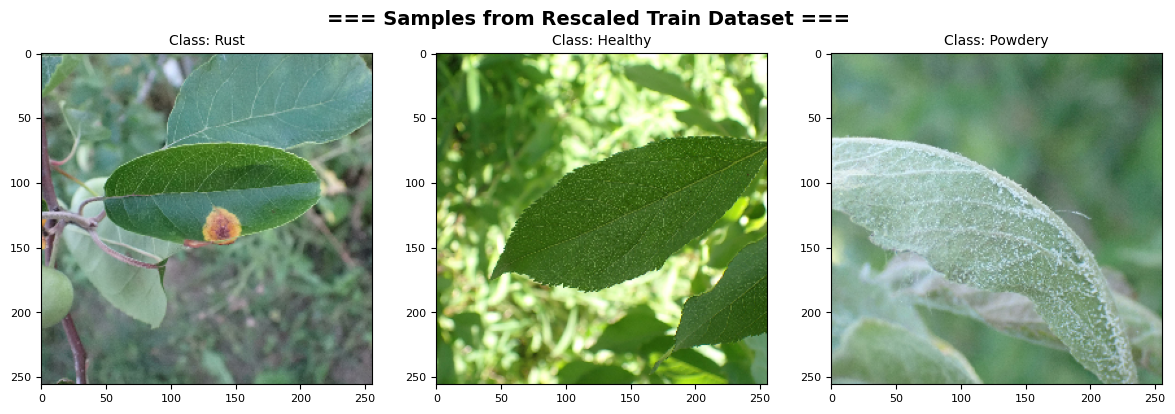

2026-07-17 21:30:17.137487: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


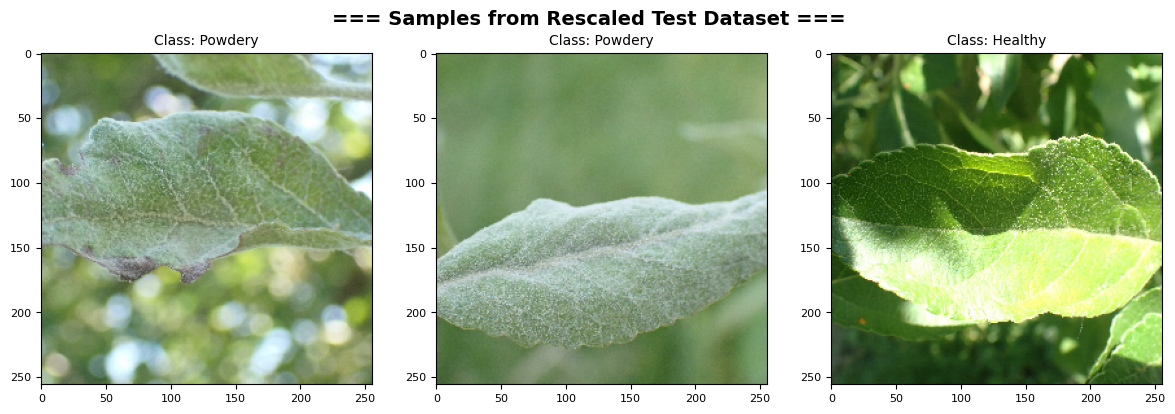

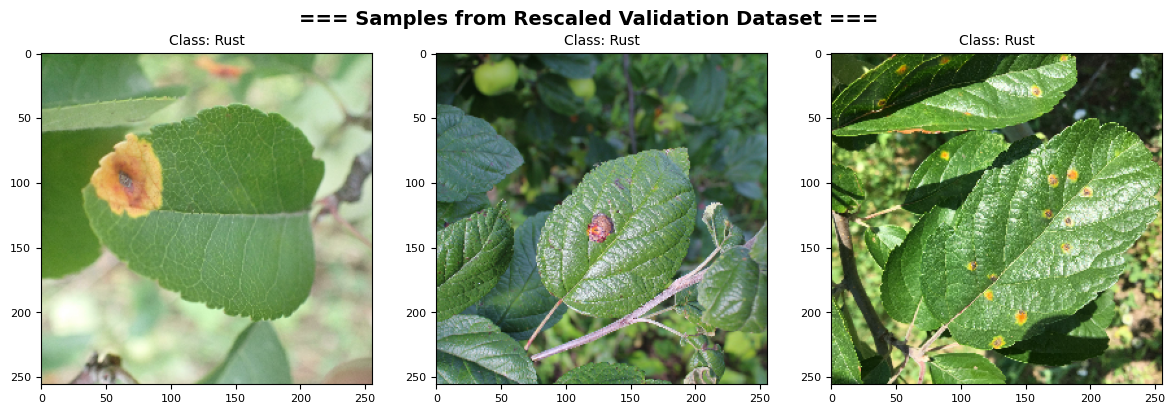

2026-07-17 21:30:18.125111: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [17]:
# A dictionary to loop through your rescaled datasets
rescaled_datasets = {
    "Rescaled Train Dataset": train,
    "Rescaled Test Dataset": test,
    "Rescaled Validation Dataset": validation
}

# Class names mapping corresponding to categorical label indices
class_names = ['Healthy', 'Powdery', 'Rust']

for name, dataset in rescaled_datasets.items():
    # .take(1) grabs the very first batch (16 images) from the pipeline
    for images, labels in dataset.take(1):
        
        # Setup a small 1x3 row plot for the current dataset
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        fig.suptitle(f"=== Samples from {name} ===", fontsize=14, fontweight='bold')
        
        for i in range(3):
            ax = axes[i]
            
            # Extract the i-th image array from the batch
            img = images[i].numpy() 
            
            # Since label_mode='categorical', labels[i] looks like [1, 0, 0]
            label_idx = labels[i].numpy().argmax()
            label_name = class_names[label_idx]
            
            # Display the normalized image matrix
            ax.imshow(img)
            ax.set_title(f"Class: {label_name}", fontsize=10)
            ax.tick_params(axis='both', which='major', labelsize=8)
            
        plt.tight_layout()
        plt.show()
        print("\n" + "="*50 + "\n")

<h3>Because you scaled the data between 0.0 and 1.0, plt.imshow handles these float values perfectly without requiring you to multiply them back by 255.</h3>

In [19]:
# Initialize min and max trackers
min_val = float('inf')
max_val = float('-inf')

# Iterate through the validation dataset batches
for images, labels in validation:
    # Convert the tensor batch to a numpy array
    images_numpy = images.numpy()
    
    # Find the min and max of the current batch
    batch_min = images_numpy.min()
    batch_max = images_numpy.max()
    
    # Update the global min and max
    if batch_min < min_val:
        min_val = batch_min
    if batch_max > max_val:
        max_val = batch_max

# Print the final formatted output
print(f"Minimum pixel value in the Validation dataset {min_val:.1f}")
print(f"Maximum pixel value in the Validation dataset {max_val:.1f}")

Minimum pixel value in the Validation dataset 0.0
Maximum pixel value in the Validation dataset 1.0


<h3>Data Augmentation</h3>

Keras has about seven different layers for image data augmentation. These are:

• tf.keras.layers.RandomCrop: This layer randomly chooses a location to crop images down to a target size.

• tf.keras.layers.RandomFlip: This layer randomly flips images horizontally and or vertically based on the mode attribute.

• tf.keras.layers.RandomTranslation: This layer randomly applies translations to each image during training according to the fill_mode attribute.

• tf.keras.layers.RandomBrightness: This layer randomly increases/reduces the brightness for the input RGB images.

• tf.keras.layers.RandomRotation: This layer randomly rotates the images during training, and also fills empty spaces according to the fill_mode attribute.

• tf.keras.layers.RandomZoom: This layer randomly zooms in or out on each axis of each image independently during training.

• tf.keras.layers.RandomContrast: This layer randomly adjusts contrast by a random factor during training in or out on each axis of each image independently during training.

In [20]:
# Creating data augmentation pipeline
augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
        factor = (-.25, .3),
        fill_mode = 'reflect',
        interpolation = 'bilinear',
        seed = seed),
        
        
        tf.keras.layers.RandomBrightness(
        factor = (-.45, .45),
        value_range = (0.0, 1.0),
        seed = seed),
        
        tf.keras.layers.RandomContrast(
        factor = (.5),
        seed = seed)
    ]
)

Besides the Convolutional, Pooling, and Fully-Connected Layers, which we have previously explored, I am also going to add the following layers to the network:

• BatchNormalization: This layer applies a transformation that maintains the mean output close to 00 and the standard deviation close to 11. It normalizes its inputs and is important to help convergence and generalization.

• Dropout: This layer randomly sets a fraction of input units to 00 during training, which helps to prevent overfitting.

• Flatten: This layer transforms a multi-dimensional tensor into a one-dimensional tensor. It is used when transitioning from the Feature Learning segment — Convolutional and Pooling layers — to the fully-connected layers.

I plan to use different kernel sizes, both 3×33×3 and 5×55×5. This may allow the network to capture features at multiple scales.

I am also gradually increasing the dropout rates as we advance through the process and the increase in the number of kernels.



In [26]:

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

tf.debugging.set_log_device_placement(True)

TensorFlow: 2.18.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
# Check for Apple Silicon GPU (MPS) availability
gpu_devices = tf.config.list_physical_devices('GPU')

if len(gpu_devices) > 0:
    print(f"Success! Found M3 GPU: {gpu_devices}")
    # On Apple Silicon, we use the default single-device strategy 
    # to let Keras automatically route tensors to the M3 graphics cores.
    strategy = tf.distribute.get_strategy() 
    print("Running on Apple Silicon GPU (MPS)")
else:
    strategy = tf.distribute.get_strategy()
    print("GPU not detected. Running on CPU fallback.")

Success! Found M3 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Running on Apple Silicon GPU (MPS)


In [22]:
# Initiating model on GPU
with strategy.scope():
    model = Sequential()

    model.add(augmentation) # Adding data augmentation pipeline to the model

    # Feature Learning Layers
    model.add(Conv2D(32,                  # Number of filters/Kernels
                     (3,3),               # Size of kernels (3x3 matrix)
                     strides = 1,         # Step size for sliding the kernel across the input (1 pixel at a time).
                     padding = 'same',    # 'Same' ensures that the output feature map has the same dimensions as the input by padding zeros around the input. 
                    input_shape = (256,256,3) # Input image shape
                    ))
    model.add(Activation('relu'))# Activation function
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size = (2,2), padding = 'same'))
    model.add(Dropout(0.2))

    model.add(Conv2D(64, (5,5), padding = 'same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size = (2,2), padding = 'same'))
    model.add(Dropout(0.2))

    model.add(Conv2D(128, (3,3), padding = 'same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size = (2,2), padding = 'same'))
    model.add(Dropout(0.3))

    model.add(Conv2D(256, (5,5), padding = 'same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size = (2,2), padding = 'same'))
    model.add(Dropout(0.3))

    model.add(Conv2D(512, (3,3), padding = 'same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size = (2,2), padding = 'same'))
    model.add(Dropout(0.3))

    # Flattening tensors
    model.add(Flatten())

    # Fully-Connected Layers
    model.add(Dense(2048))
    model.add(Activation('relu'))
    model.add(Dropout(0.5))

    # Output Layer
    model.add(Dense(3, activation = 'softmax')) # Classification layer

/Users/razzaqismath/Documents/python/tools4hack3.9/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# CNN Model & Data Flow Breakdown

This document acts as a comprehensive summary of the CNN tensor operations, layer mechanics, and spatial dimension transformations during training.

---

# 1. The Infrastructure Setup Error Fix

Before launching the model, the initialization fails if `strategy` is undefined. In TensorFlow, distributed multi-GPU/TPU setups require setting up a scope.

```python
import tensorflow as tf

# Detect hardware, select distribution strategy
devices = tf.config.list_physical_devices('GPU')

if len(devices) > 0:
    strategy = tf.distribute.MirroredStrategy()  # Uses available GPUs
    print("Running on GPU")
else:
    strategy = tf.distribute.get_strategy()      # Default CPU/GPU strategy
    print("Running on default strategy")
```

---

# 2. Deep Dive: Max Pooling & Dropout Mechanics

> **Your Question:**  
> *"I think I understand the first 3 steps. What happens at maxpooling and dropout? Maxpooling gets the output for the conv2d applied relu and normalization right?"*

**Yes, exactly!**

Keras builds an assembly line sequentially. `MaxPooling2D` processes the exact tensors coming directly out of the previous `BatchNormalization` layer.

## MaxPooling2D(pool_size=(2,2), padding='same')

### The Action

It slides a **2 × 2** window across every single feature map.

Out of every **4 pixels** enclosed in that window, it preserves only the **maximum value** and discards the other three.

### The Purpose

- Drops **75% of redundant spatial information**
- Cuts the height and width dimensions in half
- Makes computation much faster
- Introduces **translation invariance**, allowing the CNN to recognize features even if they move slightly in the image.

---

> **Your Question:**  
> *"Ok so max pooling applied to all 64 outputs of convolution layers? And what's produced at max pooling?"*

**Yes, absolutely.**

Max pooling acts on each feature map independently.

It **does not mix channels together**. Instead, it processes all **64 feature maps separately.**

## Tensor Shape Transformation

**Input to Max Pooling**

```
(128, 128, 64)
```

- 64 feature maps
- Each feature map is 128 × 128

↓

**Output from Max Pooling**

```
(64, 64, 64)
```

- Height becomes 64
- Width becomes 64
- Number of channels stays **64**

---

# 3. Forward Pass vs Optimization: Clarifying Dropout

> **Your Question:**  
> *"I think dropout happens at the optimization step? So what happens at the feedforward step? Because max pooling is 64 matrices. And what happens when you add dropout to those matrices?"*

This is a very common misconception.

**Dropout actually runs during the forward pass**, not during backpropagation.

## How Dropout (0.2) Works During Feedforward

### Step 1 — Create a Mask

Dropout creates a random binary tensor (called a **mask**) that has exactly the same shape as the input.

Example:

```
Input tensor:
(64,64,64)

Mask:
(64,64,64)
```

---

### Step 2 — Fill the Mask

For a dropout rate of **0.2**

- 80% of entries become **1**
- 20% become **0**

Example

```
1 1 1 0
0 1 1 1
1 1 0 1
...
```

---

### Step 3 — Multiply Element-by-Element

The original feature maps are multiplied with the mask.

```
Feature Value × Mask

5.3 × 1 = 5.3
2.8 × 0 = 0
8.7 × 1 = 8.7
```

Any element multiplied by **0** disappears completely.

---

## What Gets Passed to the Next Layer?

The next layer still receives

```
(64,64,64)
```

The tensor size hasn't changed.

However,

- roughly **20% of the activations**
- spread randomly throughout all 64 feature maps

have become **0**.

This forces the network to stop relying on a few "super neurons" and instead learn more robust features.

---

## What Happens During Backpropagation?

Because those dropped activations were forced to zero during the forward pass,

their gradients are also zero.

Therefore,

those neurons **do not receive weight updates** during this training iteration.

On the next mini-batch,

a completely different random mask is generated.

---

> **Your Question:**  
> *"Ok. Now explain these codes: Flatten(), Dense(2048), Activation('relu'), Dropout(0.5), and Dense(3, activation='softmax')"*

---

# 4. The Classification Stage (Transitioning from 3D to 1D)

This final stage shifts the network from

**extracting image features**

to

**making a classification decision.**

---

## Flatten()

```python
model.add(Flatten())
```

### Input

A 3D feature tensor

```
(8,8,512)
```

### What Flatten Does

Dense layers cannot work with 3D tensors.

Flatten simply unrolls everything into one long vector.

```
8 × 8 × 512

=

32,768 numbers
```

Output becomes

```
(32768,)
```

No values change.

Only the shape changes.

---

# The Dense Network Brain

```python
model.add(Dense(2048))
model.add(Activation('relu'))
model.add(Dropout(0.5))
```

---

## Dense(2048)

Creates a fully connected layer with

**2,048 neurons.**

Each neuron connects to **every one** of the

32,768 input values.

This allows the network to combine all learned image features together before making a decision.

---

## Activation('relu')

Applies the ReLU function

```
ReLU(x) = max(0,x)
```

Negative values become zero.

Positive values remain unchanged.

This introduces non-linearity so the network can learn complex patterns.

---

## Dropout(0.5)

Dense layers usually contain **millions of parameters**, making them prone to overfitting.

With

```
Dropout(0.5)
```

half of the **2,048 neurons**

are randomly disabled during each training step.

This forces the network to distribute learning across many neurons instead of depending on only a few.

---

# The Final Output Layer

```python
model.add(Dense(3, activation='softmax'))
```

---

## Dense(3)

The final layer contains

**3 neurons**

because there are

**3 output classes.**

For example

- Healthy
- Rust Disease
- Mildew

Each neuron produces one raw score (called a **logit**).

---

## activation='softmax'

Softmax converts the raw scores into probabilities.

Example

Raw outputs

```
[5.3, 2.1, 0.4]
```

↓

Softmax

```
[0.93, 0.05, 0.02]
```

Properties:

- Every probability lies between **0 and 1**
- All probabilities add up to **1.0 (100%)**
- The class with the highest probability becomes the model's prediction.

In [23]:
# Compiling model
model.compile(optimizer = tf.keras.optimizers.RMSprop(0.0001), # 1e-4
              loss = 'categorical_crossentropy', # Ideal for multiclass tasks
              metrics = ['accuracy']) # Evaluation metric

In [28]:
# Defining an Early Stopping and Model Checkpoints. 
# patience 10 will stop if accuracy didn't improve within 10 epochs
early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, mode='max', restore_best_weights=True)

# Change 'best_model.h5' to 'best_model.keras'
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)

In [29]:
history = model.fit(
    train,
    validation_data=validation,
    epochs=50,
    callbacks=[early_stopping, checkpoint]  # <--- Pass them here
)

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 45s 468ms/step - accuracy: 0.6649 - loss: 5.2883 - val_accuracy: 0.3333 - val_loss: 28.3860
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 413ms/step - accuracy: 0.7148 - loss: 4.9541 - val_accuracy: 0.3333 - val_loss: 38.8817
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.7650 - loss: 4.3630 - val_accuracy: 0.3333 - val_loss: 45.9791
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 55s 657ms/step - accuracy: 0.7640 - loss: 4.1818 - val_accuracy: 0.3333 - val_loss: 42.8844
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 68s 824ms/step - accuracy: 0.8187 - loss: 3.6557 - val_accuracy: 0.4000 - val_loss: 12.2661
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 78s 937ms/step - accuracy: 0.7931 - loss: 4.3012 - val_accuracy: 0.3833 - val_loss: 34.2422
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 65s 776ms/step - accuracy: 0.8373 - loss: 5.0816 - val_accuracy: 0.6333 - val_loss: 5.4445
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 57s 676ms/step - accuracy: 0.8265 - loss: 5.4922 - val_

KeyboardInterrupt: 

In [30]:
model.save("my_model.keras")